In [90]:
import polars as pl
import os
import polars.selectors as cs
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
import seaborn as sns
import numpy as np


In [91]:
(supreme_full := pl.read_csv("./data/supreme_data.csv"))

,name,birth_date,birth_st,gender,race,religion,state,party,president,senate_aye,senate_nay,term_start,term_end,death_date
str,str,str,str,str,str,str,str,str,i64,i64,i64,str,str,str
null,"""Jay, John""","""1745-12-12""","""NY""","""M""","""White""","""episcopalian""","""NY""","""Federalist""",1,null,null,"""1789-10-19""","""1795-06-29""","""1829-05-17"""
null,"""Rutledge, John""","""1739-09-18""","""SC""","""M""","""White""","""episcopalian""","""SC""","""Federalist""",1,null,null,"""1790-02-15""","""1791-03-05""","""1800-07-18"""
null,"""Cushing, William""","""1732-03-01""","""MA""","""M""","""White""","""congregationalist""","""MA""","""Federalist""",1,null,null,"""1790-02-02""","""1810-09-13""","""1810-09-13"""
null,"""Wilson, James""","""1742-09-14""","""N/A""","""M""","""White""","""episcopalian""","""PA""","""Federalist""",1,null,null,"""1789-10-05""","""1798-08-21""","""1798-08-21"""
null,"""Blair, John, Jr.""","""1732-04-17""","""VA""","""M""","""White""","""episcopalian""","""VA""","""Federalist""",1,null,null,"""1790-02-02""","""1796-01-27""","""1800-08-31"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
null,"""Sotomayor, Sonia Maria""","""1954-06-25""","""NY""","""F""","""Hispanic""",""" roman catholic""","""NY""","""Democrat""",44,68,31,"""2009-09-09""",null,null
null,"""Kagan, Elena""","""1960-04-08""","""NY""","""F""","""White""","""jewish""","""MA""","""Democrat""",44,63,37,"""2010-08-07""",null,null
null,"""Gorsuch, Neil McGill""","""1967-08-29""","""CO""","""M""","""White""","""episcopalian""","""CO""","""Republican""",45,54,45,"""2017-04-10""",null,null


In [92]:
# extract death year from date of death and create a new column for it
supreme_full = supreme_full.with_columns(pl.col("death_date").str.extract(r"(\d{4})").cast(pl.Int32).alias("death_year"))

In [93]:
# exclude rows with missing death year, they will become test data later
(supreme := supreme_full.filter(pl.col("death_year").is_not_null()))

,name,birth_date,birth_st,gender,race,religion,state,party,president,senate_aye,senate_nay,term_start,term_end,death_date,death_year
str,str,str,str,str,str,str,str,str,i64,i64,i64,str,str,str,i32
null,"""Jay, John""","""1745-12-12""","""NY""","""M""","""White""","""episcopalian""","""NY""","""Federalist""",1,null,null,"""1789-10-19""","""1795-06-29""","""1829-05-17""",1829
null,"""Rutledge, John""","""1739-09-18""","""SC""","""M""","""White""","""episcopalian""","""SC""","""Federalist""",1,null,null,"""1790-02-15""","""1791-03-05""","""1800-07-18""",1800
null,"""Cushing, William""","""1732-03-01""","""MA""","""M""","""White""","""congregationalist""","""MA""","""Federalist""",1,null,null,"""1790-02-02""","""1810-09-13""","""1810-09-13""",1810
null,"""Wilson, James""","""1742-09-14""","""N/A""","""M""","""White""","""episcopalian""","""PA""","""Federalist""",1,null,null,"""1789-10-05""","""1798-08-21""","""1798-08-21""",1798
null,"""Blair, John, Jr.""","""1732-04-17""","""VA""","""M""","""White""","""episcopalian""","""VA""","""Federalist""",1,null,null,"""1790-02-02""","""1796-01-27""","""1800-08-31""",1800
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
null,"""Powell, Lewis Franklin, Jr.""","""1907-09-19""","""VA""","""M""","""White""",""" presbyterian""","""VA""","""Democrat""",37,89,1,"""1972-01-07""","""1987-06-26""","""1998-08-25""",1998
null,"""Rehnquist, William Hubbs""","""1924-10-01""","""WI""","""M""","""White""","""lutheran""","""AZ""","""Republican""",37,68,26,"""1972-01-07""","""2005-09-03""","""2005-09-03""",2005
null,"""Stevens, John Paul""","""1920-04-20""","""IL""","""M""","""White""",""" protestant""","""IL""","""Republican""",38,98,0,"""1975-12-19""","""2010-06-30""","""2019-07-16""",2019


In [94]:
# rewrite birth_date , term start_date and term end date as year only
supreme = supreme.with_columns([
    pl.col("birth_date").str.extract(r"(\d{4})").cast(pl.Int32).alias("birth_year"),
    pl.col("term_start").str.extract(r"(\d{4})").cast(pl.Int32).alias("term_start_year"),
    pl.col("term_end").str.extract(r"(\d{4})").cast(pl.Int32).alias("term_end_year"),
])
#drop the empty column
supreme = supreme.drop(supreme.columns[1])

In [95]:
# find death age by subtracting birth year from death year
supreme = supreme.with_columns(
    (pl.col("death_year") - pl.col("birth_year")).alias("death_age")
)


In [96]:
# add new column that finds how old they were when they were appointed to the supreme court
(supreme := supreme.with_columns((pl.col("term_start_year") - pl.col("birth_year")).alias("age_at_appointment")))

,birth_date,birth_st,gender,race,religion,state,party,president,senate_aye,senate_nay,term_start,term_end,death_date,death_year,birth_year,term_start_year,term_end_year,death_age,age_at_appointment
str,str,str,str,str,str,str,str,i64,i64,i64,str,str,str,i32,i32,i32,i32,i32,i32
null,"""1745-12-12""","""NY""","""M""","""White""","""episcopalian""","""NY""","""Federalist""",1,null,null,"""1789-10-19""","""1795-06-29""","""1829-05-17""",1829,1745,1789,1795,84,44
null,"""1739-09-18""","""SC""","""M""","""White""","""episcopalian""","""SC""","""Federalist""",1,null,null,"""1790-02-15""","""1791-03-05""","""1800-07-18""",1800,1739,1790,1791,61,51
null,"""1732-03-01""","""MA""","""M""","""White""","""congregationalist""","""MA""","""Federalist""",1,null,null,"""1790-02-02""","""1810-09-13""","""1810-09-13""",1810,1732,1790,1810,78,58
null,"""1742-09-14""","""N/A""","""M""","""White""","""episcopalian""","""PA""","""Federalist""",1,null,null,"""1789-10-05""","""1798-08-21""","""1798-08-21""",1798,1742,1789,1798,56,47
null,"""1732-04-17""","""VA""","""M""","""White""","""episcopalian""","""VA""","""Federalist""",1,null,null,"""1790-02-02""","""1796-01-27""","""1800-08-31""",1800,1732,1790,1796,68,58
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
null,"""1907-09-19""","""VA""","""M""","""White""",""" presbyterian""","""VA""","""Democrat""",37,89,1,"""1972-01-07""","""1987-06-26""","""1998-08-25""",1998,1907,1972,1987,91,65
null,"""1924-10-01""","""WI""","""M""","""White""","""lutheran""","""AZ""","""Republican""",37,68,26,"""1972-01-07""","""2005-09-03""","""2005-09-03""",2005,1924,1972,2005,81,48
null,"""1920-04-20""","""IL""","""M""","""White""",""" protestant""","""IL""","""Republican""",38,98,0,"""1975-12-19""","""2010-06-30""","""2019-07-16""",2019,1920,1975,2010,99,55


In [97]:
# set our machine learningpredictor variable as death date
y = supreme["death_age"]

In [98]:
# set up each feature manually
# use birth year, term start year and term end year, gender, race, religion, state, age at appointment as features
X = supreme.select([
    "birth_year",
    "term_start_year",
    "term_end_year",
    "gender",
    "race",
    "religion",
    "state",
    "age_at_appointment"
])


In [99]:
X.head()

birth_year,term_start_year,term_end_year,gender,race,religion,state,age_at_appointment
i32,i32,i32,str,str,str,str,i32
1745,1789,1795,"""M""","""White""","""episcopalian""","""NY""",44
1739,1790,1791,"""M""","""White""","""episcopalian""","""SC""",51
1732,1790,1810,"""M""","""White""","""congregationalist""","""MA""",58
1742,1789,1798,"""M""","""White""","""episcopalian""","""PA""",47
1732,1790,1796,"""M""","""White""","""episcopalian""","""VA""",58


In [100]:
# find which x columns are numeric and which are categorical
num_columns = X.select(pl.col(pl.Float64, pl.Int32)).columns
cat_columns = X.select(pl.col(pl.Utf8)).columns

In [101]:
(preprocess :=
 make_column_transformer(
     (OneHotEncoder(), cat_columns),
     (StandardScaler(), num_columns),
 )

)
# one hot for categorical, standard scale for numeric

,transformers,"[('onehotencoder', ...), ('standardscaler', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,True


In [102]:
supreme.head()

,birth_date,birth_st,gender,race,religion,state,party,president,senate_aye,senate_nay,term_start,term_end,death_date,death_year,birth_year,term_start_year,term_end_year,death_age,age_at_appointment
str,str,str,str,str,str,str,str,i64,i64,i64,str,str,str,i32,i32,i32,i32,i32,i32
null,"""1745-12-12""","""NY""","""M""","""White""","""episcopalian""","""NY""","""Federalist""",1,null,null,"""1789-10-19""","""1795-06-29""","""1829-05-17""",1829,1745,1789,1795,84,44
null,"""1739-09-18""","""SC""","""M""","""White""","""episcopalian""","""SC""","""Federalist""",1,null,null,"""1790-02-15""","""1791-03-05""","""1800-07-18""",1800,1739,1790,1791,61,51
null,"""1732-03-01""","""MA""","""M""","""White""","""congregationalist""","""MA""","""Federalist""",1,null,null,"""1790-02-02""","""1810-09-13""","""1810-09-13""",1810,1732,1790,1810,78,58
null,"""1742-09-14""","""N/A""","""M""","""White""","""episcopalian""","""PA""","""Federalist""",1,null,null,"""1789-10-05""","""1798-08-21""","""1798-08-21""",1798,1742,1789,1798,56,47
null,"""1732-04-17""","""VA""","""M""","""White""","""episcopalian""","""VA""","""Federalist""",1,null,null,"""1790-02-02""","""1796-01-27""","""1800-08-31""",1800,1732,1790,1796,68,58


Start modeling

In [103]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer

In [104]:
# set up test-train split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [105]:
# make knn model with preprocess pipeline
model_knn = make_pipeline(
    preprocess,
    KNeighborsRegressor(n_neighbors=5, weights="distance")
)

In [106]:
# Convert Polars to pandas
X_train_pd = X_train.to_pandas()
X_test_pd = X_test.to_pandas()
y_train_pd = y_train.to_pandas()  # Convert Polars Series to pandas Series

# fit knn model
model_knn.fit(X_train_pd, y_train_pd)

,steps,"[('columntransformer', ...), ('kneighborsregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehotencoder', ...), ('standardscaler', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [107]:
# set up ols model with preprocess pipeline
from sklearn.linear_model import LinearRegression


model_ols = make_pipeline(
    preprocess,
    LinearRegression()
)   

In [108]:
# fit ols model
model_ols.fit(X_train_pd, y_train_pd)


,steps,"[('columntransformer', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehotencoder', ...), ('standardscaler', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [109]:
# set up a random forest model with preprocess pipeline
from sklearn.ensemble import RandomForestRegressor
model_rf = make_pipeline(
    preprocess,
    RandomForestRegressor(n_estimators=100, random_state=42)
)

In [110]:
# fit random forest model
model_rf.fit(X_train_pd, y_train_pd)

,steps,"[('columntransformer', ...), ('randomforestregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehotencoder', ...), ('standardscaler', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Grid search to find best model

In [111]:
from sklearn.model_selection import cross_val_score

models = {
    'KNN': model_knn,
    'OLS': model_ols,
    'Random Forest': model_rf
}

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train_pd, y_train_pd, cv=5, scoring='neg_mean_absolute_error')
    results[name] = {
        'mean': scores.mean(),
        'std': scores.std(),
        'scores': scores
    }

# Find best model
best_model_name = max(results, key=lambda k: results[k]['mean'])
best_model_name

c:\Users\ke9712wb\AppData\Local\anaconda3\envs\polars\Lib\site-packages\sklearn\model_selection\_validation.py:971: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\ke9712wb\AppData\Local\anaconda3\envs\polars\Lib\site-packages\sklearn\metrics\_scorer.py", line 152, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "c:\Users\ke9712wb\AppData\Local\anaconda3\envs\polars\Lib\site-packages\sklearn\metrics\_scorer.py", line 400, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "c:\Users\ke9712wb\AppData\Local\anaconda3\envs\polars\Lib\site-packages\sklearn\metrics\_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
                ^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ke9712wb\AppData\Local\anaconda3\envs\polars\Lib\site-packages\sklearn\utils\_response.py", line 242, in _get_response_values
    y_p

'KNN'

Predict when Supreme Court Justices will die

In [112]:
# filter the original supreme_full dataframe to only include rows where death_year is null, this will be our 2nd test set
supreme_test_2 = supreme_full.filter(pl.col("death_date").is_null())

In [113]:
# First, add the year columns
supreme_test_2 = supreme_test_2.with_columns([
    pl.col("birth_date").str.extract(r"(\d{4})").cast(pl.Int32).alias("birth_year"),
    pl.col("term_start").str.extract(r"(\d{4})").cast(pl.Int32).alias("term_start_year"),
    pl.col("term_end").str.extract(r"(\d{4})").cast(pl.Int32).alias("term_end_year"),
])

# Then, calculate age_at_appointment using the newly created columns
supreme_test_2 = supreme_test_2.with_columns(
    (pl.col("term_start_year") - pl.col("birth_year")).alias("age_at_appointment")
)

In [114]:
# predict death dates of the 2nd test set using the best model
X_test_2 = supreme_test_2.select([
    "birth_year",
    "term_start_year",
    "term_end_year",
    "gender",
    "race",
    "religion",
    "state",
    "age_at_appointment"
])

In [115]:
(preprocess :=
 make_column_transformer(
     (OneHotEncoder(handle_unknown='ignore'), cat_columns),
     (StandardScaler(), num_columns),
 )
)
# one hot for categorical, standard scale for numeric

,transformers,"[('onehotencoder', ...), ('standardscaler', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,True


In [116]:
# Recreate all models with the updated preprocessor
model_knn = make_pipeline(preprocess, KNeighborsRegressor(n_neighbors=5))
model_knn.fit(X_train_pd, y_train_pd)

model_ols = make_pipeline(preprocess, LinearRegression())
model_ols.fit(X_train_pd, y_train_pd)

model_rf = make_pipeline(preprocess, RandomForestRegressor(n_estimators=100, random_state=42))
model_rf.fit(X_train_pd, y_train_pd)

# Update the models dictionary
models = {
    'KNN': model_knn,
    'OLS': model_ols,
    'Random Forest': model_rf
}
models


{'KNN': Pipeline(steps=[('columntransformer',
                  ColumnTransformer(transformers=[('onehotencoder',
                                                   OneHotEncoder(handle_unknown='ignore'),
                                                   ['gender', 'race', 'religion',
                                                    'state']),
                                                  ('standardscaler',
                                                   StandardScaler(),
                                                   ['birth_year',
                                                    'term_start_year',
                                                    'term_end_year',
                                                    'age_at_appointment'])])),
                 ('kneighborsregressor', KNeighborsRegressor())]),
 'OLS': Pipeline(steps=[('columntransformer',
                  ColumnTransformer(transformers=[('onehotencoder',
                                              

In [117]:
# Convert X_test_2 to pandas for prediction
X_test_final_pd = X_test_2.to_pandas()

In [118]:
from sklearn.impute import SimpleImputer
import pandas as pd

# Impute categorical columns with 'most_frequent'
imputer_cat = SimpleImputer(strategy='most_frequent')
X_test_cat = imputer_cat.fit_transform(X_test_final_pd[cat_columns])

# Impute numeric columns with 'mean'
imputer_num = SimpleImputer(strategy='mean')
X_test_num = imputer_num.fit_transform(X_test_final_pd[num_columns])

# Combine them back together in the correct column order
X_test_imputed = pd.concat([
    pd.DataFrame(X_test_num, columns=num_columns),
    pd.DataFrame(X_test_cat, columns=cat_columns)
], axis=1)

predicted_death_ages = model_knn.predict(X_test_imputed)

In [123]:
# Use KNN model to predict death ages for justices without death years
predicted_death_ages = model_knn.predict(X_test_imputed)
# Add predictions to the dataframe
supreme_test_2 = supreme_test_2.with_columns(
    pl.Series("predicted_death_age", predicted_death_ages).cast(pl.Int32)
)

# Calculate predicted death year by adding predicted death age to birth year
supreme_test_2 = supreme_test_2.with_columns(
    (pl.col("birth_year") + pl.col("predicted_death_age")).alias("predicted_death_year")
)

# Display results with names and predictions
supreme_test_2.select([
    "name",
    "birth_year",
    "predicted_death_age",
    "predicted_death_year"
])


name,birth_year,predicted_death_age,predicted_death_year
str,i32,i32,i32
"""O'Connor, Sandra Day""",1930,78,2008
"""Kennedy, Anthony McLeod""",1936,82,2018
"""Souter, David H.""",1939,78,2017
"""Thomas, Clarence""",1948,76,2024
"""Breyer, Stephen G.""",1938,83,2021
…,…,…,…
"""Sotomayor, Sonia Maria""",1954,85,2039
"""Kagan, Elena""",1960,85,2045
"""Gorsuch, Neil McGill""",1967,84,2051


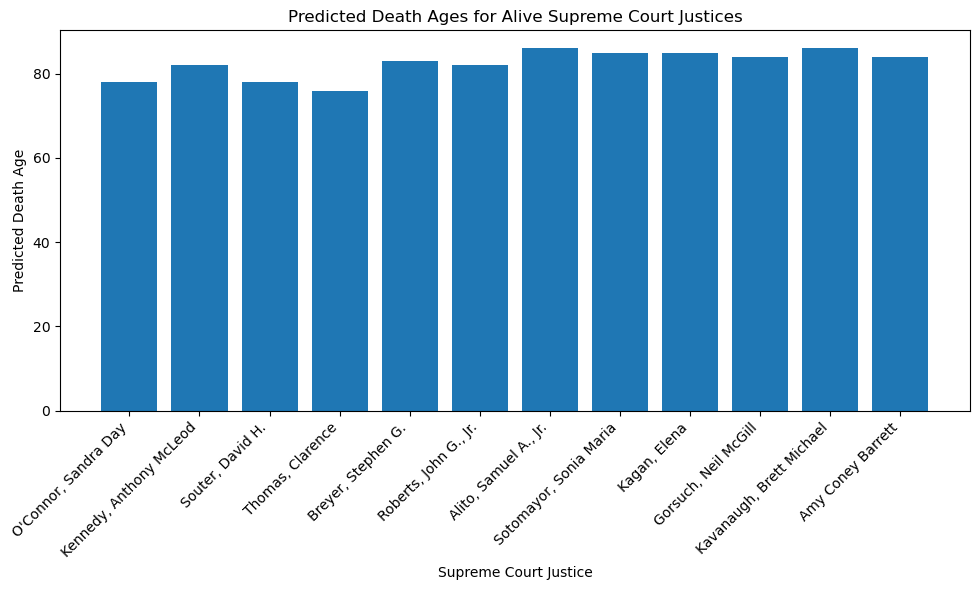

In [124]:
# make a bar graph for alive supreme court justices and their predicted death ages
import matplotlib.pyplot as plt

# Select only alive justices (where death_year is null)
alive_justices = supreme_test_2.filter(pl.col("death_year").is_null())

# Create bar graph
plt.figure(figsize=(10, 6))
plt.bar(alive_justices["name"], alive_justices["predicted_death_age"])
plt.xlabel("Supreme Court Justice")
plt.ylabel("Predicted Death Age")
plt.title("Predicted Death Ages for Alive Supreme Court Justices")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()